# Notebook 5 — Model Training and Comparison
## Telecom Customer Retention Intelligence Platform

**Objective:** Train four classification models, compare performance
using business-relevant metrics, and select the best model
for deployment.

**Input:** data/processed/telco_churn_featured.csv  
**Key Metric:** Recall — minimizing missed churners  


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, recall_score,
    precision_score, f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
import pickle

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
df = pd.read_csv('../data/processed/telco_churn_featured.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total features: {df.shape[1] - 1}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].mean()*100:.1f}%")

Dataset shape: (7043, 39)
Total features: 38

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%


## 2. Prepare Features and Target

In [5]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (7043, 38)
Target shape: (7043,)


## 3. Train Test Split
Stratified split preserves the 27% churn ratio in both sets.
Split BEFORE applying SMOTE to prevent data leakage.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"\nTraining churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate: {y_test.mean()*100:.1f}%")

Training set: 5,634 rows
Test set: 1,409 rows

Training churn rate: 26.5%
Test churn rate: 26.5%


## 4. Apply SMOTE — Training Data Only
Balances the class distribution in training set.
Test set remains untouched — represents real world data.

In [7]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — Training samples: {X_train.shape[0]:,}")
print(f"After SMOTE  — Training samples: "
      f"{X_train_smote.shape[0]:,}")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE — Training samples: 5,634
After SMOTE  — Training samples: 8,278

Class distribution after SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


## 5. Feature Scaling
StandardScaler applied to numerical features.
Fit on training data only — transform both sets.

In [8]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
                  'ServiceCount']

scaler = StandardScaler()

X_train_smote[numerical_cols] = scaler.fit_transform(
    X_train_smote[numerical_cols]
)
X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

print("Scaling complete")
print(f"\nNumerical features scaled: {numerical_cols}")

Scaling complete

Numerical features scaled: ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount']


## 6. Define Models
Four models trained on identical data for fair comparison.

In [9]:
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        class_weight='balanced',
        max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        max_depth=5
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_estimators=100
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        scale_pos_weight=3,
        n_estimators=100,
        eval_metric='logloss',
        verbosity=0
    )
}

print("Models defined:")
for name in models:
    print(f"  - {name}")

Models defined:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - XGBoost


## 7. Train and Evaluate All Models
Each model is trained and evaluated on identical splits.
Primary metric is Recall — minimizing missed churners.

In [10]:
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_smote, y_train_smote)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Store metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    }
    
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy:  {results[name]['Accuracy']:.3f}")
    print(f"  Recall:    {results[name]['Recall']:.3f}")
    print(f"  Precision: {results[name]['Precision']:.3f}")
    print(f"  F1 Score:  {results[name]['F1 Score']:.3f}")
    print(f"  AUC-ROC:   {results[name]['AUC-ROC']:.3f}")

print("\nAll models trained successfully")


  Logistic Regression
  Accuracy:  0.778
  Recall:    0.599
  Precision: 0.579
  F1 Score:  0.589
  AUC-ROC:   0.833

  Decision Tree
  Accuracy:  0.715
  Recall:    0.717
  Precision: 0.476
  F1 Score:  0.572
  AUC-ROC:   0.797

  Random Forest
  Accuracy:  0.768
  Recall:    0.570
  Precision: 0.562
  F1 Score:  0.566
  AUC-ROC:   0.815

  XGBoost
  Accuracy:  0.744
  Recall:    0.727
  Precision: 0.513
  F1 Score:  0.602
  AUC-ROC:   0.810

All models trained successfully


## 8. Comparison Table and Visualization

In [11]:
results_df = pd.DataFrame(results).T
results_df = results_df.round(3)

print("Model Comparison Table")
print("=" * 60)
print(results_df.to_string())
print("\nBest model by Recall:")
print(f"  {results_df['Recall'].idxmax()} — "
      f"{results_df['Recall'].max():.3f}")
print("\nBest model by AUC-ROC:")
print(f"  {results_df['AUC-ROC'].idxmax()} — "
      f"{results_df['AUC-ROC'].max():.3f}")

Model Comparison Table
                     Accuracy  Recall  Precision  F1 Score  AUC-ROC
Logistic Regression     0.778   0.599      0.579     0.589    0.833
Decision Tree           0.715   0.717      0.476     0.572    0.797
Random Forest           0.768   0.570      0.562     0.566    0.815
XGBoost                 0.744   0.727      0.513     0.602    0.810

Best model by Recall:
  XGBoost — 0.727

Best model by AUC-ROC:
  Logistic Regression — 0.833


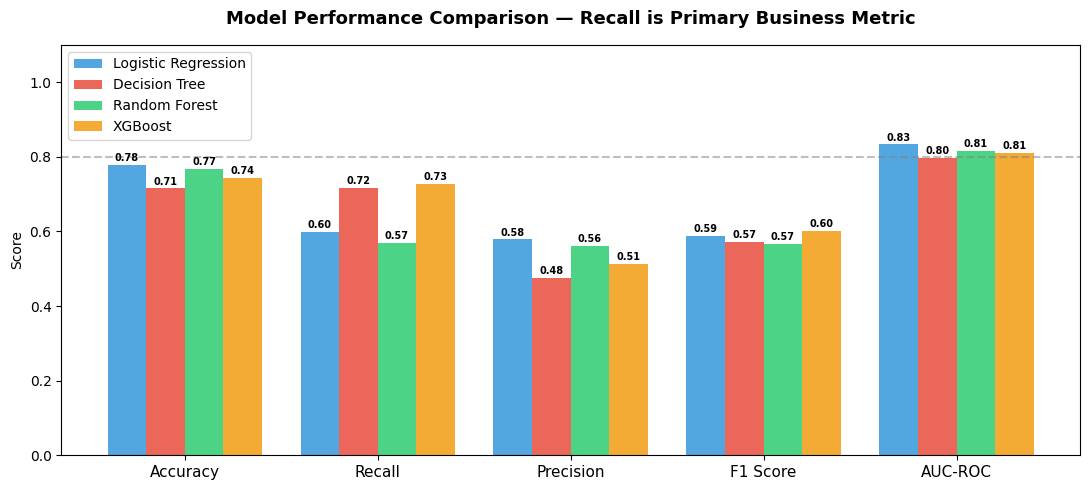

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))

metrics = ['Accuracy', 'Recall', 'Precision', 'F1 Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.2
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (model_name, color) in enumerate(
    zip(results_df.index, colors)
):
    bars = ax.bar(x + i * width,
                  results_df.loc[model_name, metrics],
                  width, label=model_name,
                  color=color, edgecolor='none', alpha=0.85)

ax.set_title('Model Performance Comparison — '
             'Recall is Primary Business Metric',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.axhline(y=0.8, color='gray', linestyle='--',
           alpha=0.5, label='0.8 target line')

for i, (model_name, color) in enumerate(
    zip(results_df.index, colors)
):
    for j, metric in enumerate(metrics):
        val = results_df.loc[model_name, metric]
        ax.text(j + i * width, val + 0.01,
                f'{val:.2f}', ha='center',
                fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 9. Confusion Matrices — All Models

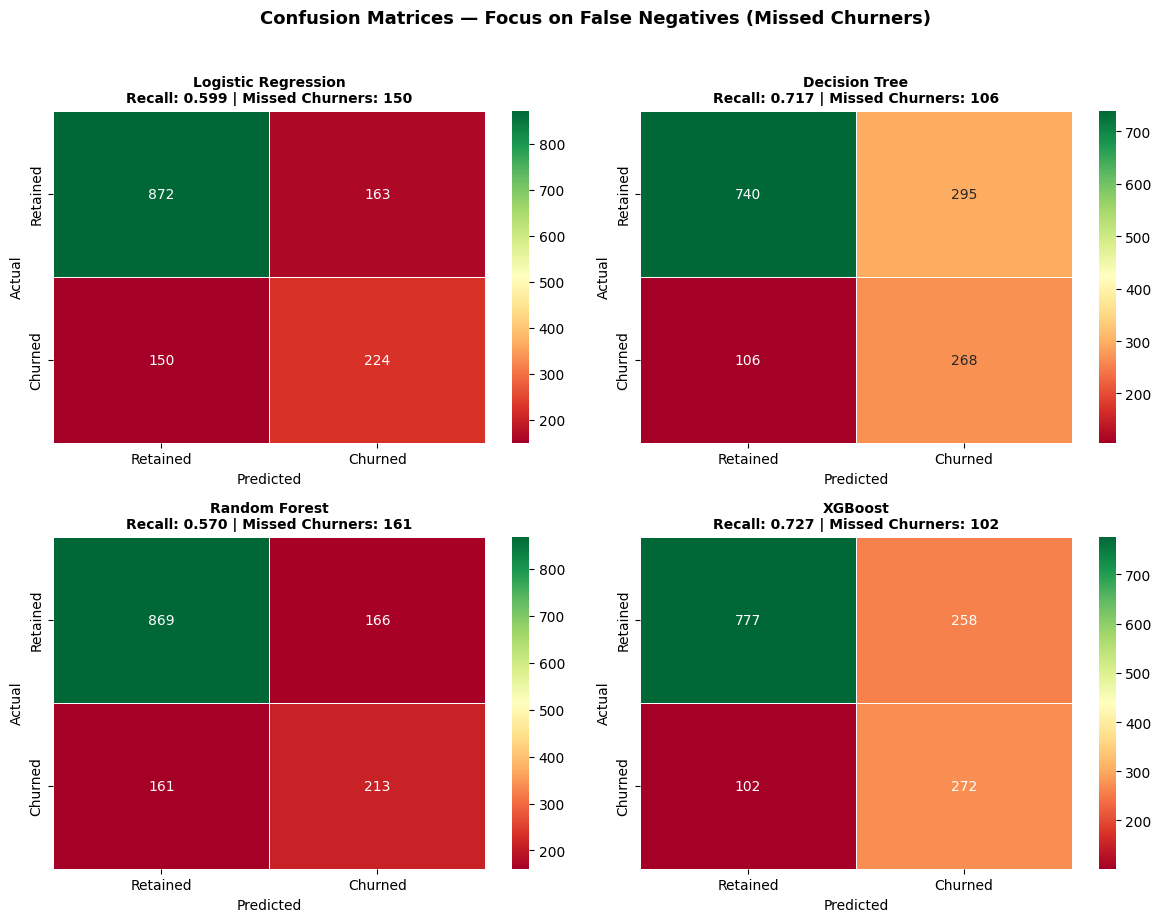

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='RdYlGn', ax=axes[i],
                linewidths=0.5,
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'])
    
    tn, fp, fn, tp = cm.ravel()
    axes[i].set_title(
        f'{name}\n'
        f'Recall: {results[name]["Recall"]:.3f} | '
        f'Missed Churners: {fn}',
        fontsize=10, fontweight='bold'
    )
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Focus on False Negatives '
             '(Missed Churners)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 10. ROC Curves — All Models

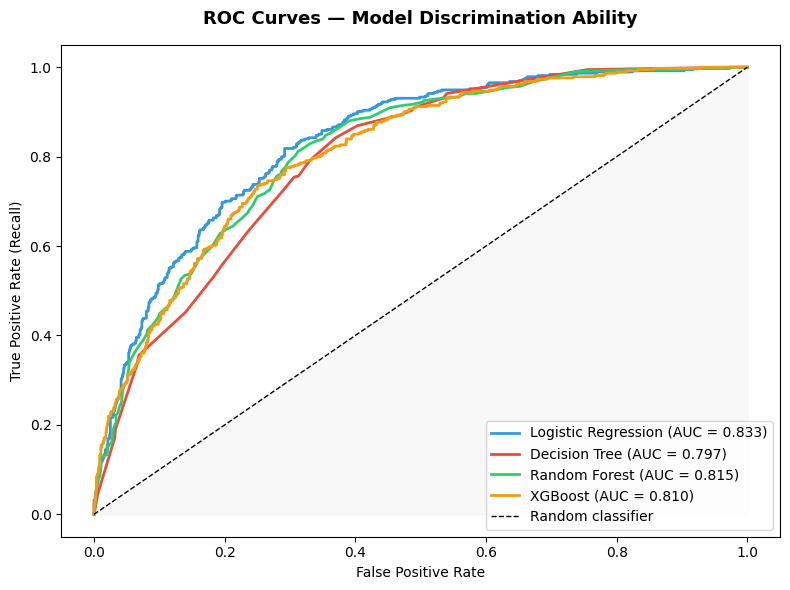

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--',
        linewidth=1, label='Random classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_title('ROC Curves — Model Discrimination Ability',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('../reports/roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 11. Select and Save Best Model

In [15]:
# Select best model by Recall
best_model_name = results_df['Recall'].idxmax()
best_model = models[best_model_name]

print(f"Best model selected: {best_model_name}")
print(f"Recall:   {results_df.loc[best_model_name, 'Recall']:.3f}")
print(f"F1 Score: {results_df.loc[best_model_name, 'F1 Score']:.3f}")
print(f"AUC-ROC:  {results_df.loc[best_model_name, 'AUC-ROC']:.3f}")

# Save model
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
feature_names = list(X.columns)
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("\nSaved to models/:")
print("  - best_model.pkl")
print("  - scaler.pkl")
print("  - feature_names.pkl")

Best model selected: XGBoost
Recall:   0.727
F1 Score: 0.602
AUC-ROC:  0.810

Saved to models/:
  - best_model.pkl
  - scaler.pkl
  - feature_names.pkl
